# 03 - Extension Analysis: XGBoost vs. LightGBM vs. CatBoost

Visualize the accuracy-vs-efficiency trade-offs from
`results/extension_results.json`. See `docs/extension_plan.md` for the
extension's motivation and `results/extension_results.md` for the full
written analysis.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path.cwd().parent / "results"

data = json.loads((RESULTS_DIR / "extension_results.json").read_text())
df = pd.DataFrame(data["results"]).set_index("library")
df

,train_seconds,train_seconds_std,inference_seconds,inference_seconds_std,model_size_bytes,best_iteration,accuracy,error_rate,auc,log_loss,f1
library,,,,,,,,,,,
xgboost,0.698616,0.0,0.015692,0.000390,480337,141,0.874631,0.125369,0.929313,0.276506,0.716530
lightgbm,0.455633,0.0,0.023764,0.001396,242401,111,0.873032,0.126968,0.928949,0.277360,0.712596
catboost,10.960484,0.0,0.009619,0.000764,332516,219,0.874078,0.125922,0.928682,0.277922,0.711142


## Accuracy / AUC: all three libraries are close

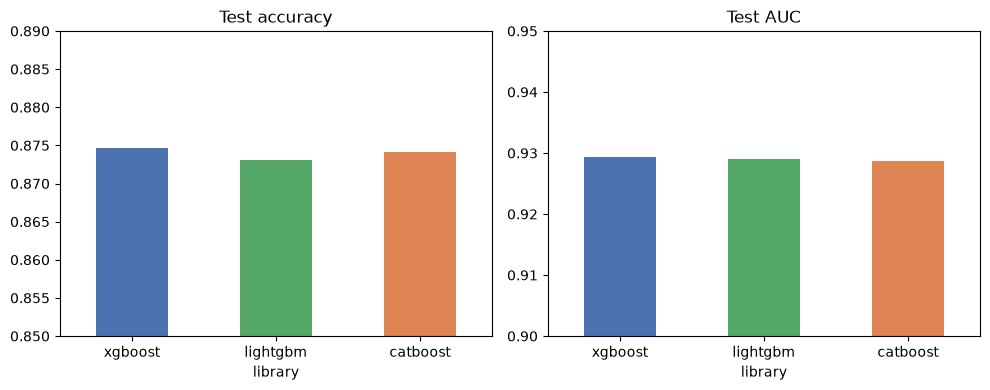

In [2]:
colors = {"xgboost": "#4C72B0", "lightgbm": "#55A868", "catboost": "#DD8452"}
bar_colors = [colors[lib] for lib in df.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["accuracy"].plot(kind="bar", ax=axes[0], color=bar_colors)
axes[0].set_title("Test accuracy")
axes[0].set_ylim(0.85, 0.89)
axes[0].tick_params(axis="x", rotation=0)

df["auc"].plot(kind="bar", ax=axes[1], color=bar_colors)
axes[1].set_title("Test AUC")
axes[1].set_ylim(0.9, 0.95)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../results/extension_accuracy_comparison.png", dpi=150)
plt.show()

## Efficiency: training time, inference time, model size

Note the log scale on training time -- CatBoost's ordered boosting is
an order of magnitude slower to train here, while being the fastest at
inference thanks to oblivious trees.

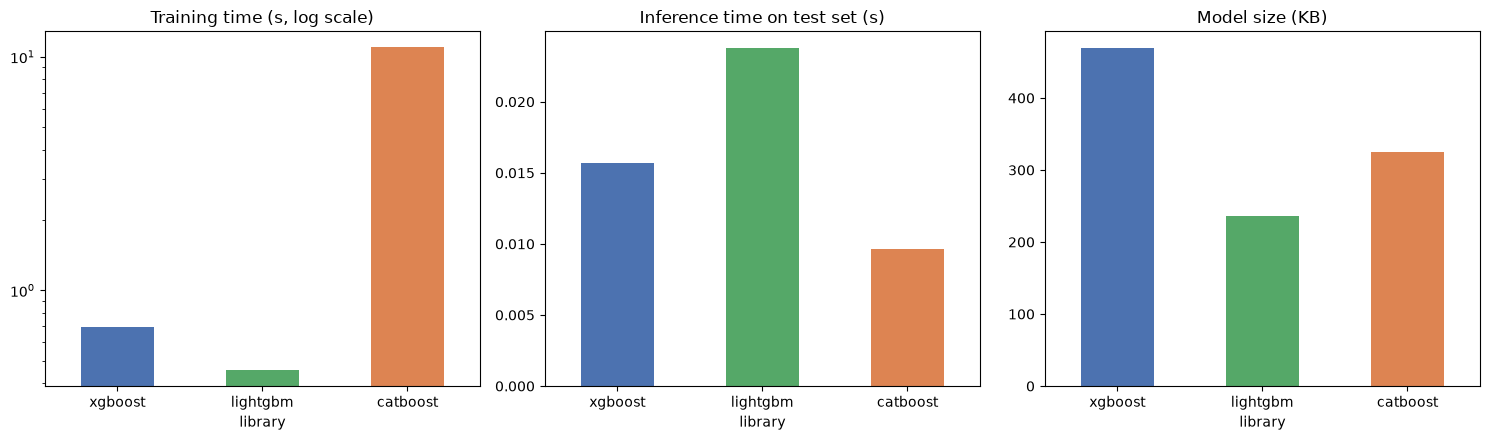

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

df["train_seconds"].plot(kind="bar", ax=axes[0], color=bar_colors, logy=True)
axes[0].set_title("Training time (s, log scale)")
axes[0].tick_params(axis="x", rotation=0)

df["inference_seconds"].plot(kind="bar", ax=axes[1], color=bar_colors)
axes[1].set_title("Inference time on test set (s)")
axes[1].tick_params(axis="x", rotation=0)

(df["model_size_bytes"] / 1024).plot(kind="bar", ax=axes[2], color=bar_colors)
axes[2].set_title("Model size (KB)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../results/extension_efficiency_comparison.png", dpi=150)
plt.show()

## Accuracy vs. training time scatter

The clearest single view of the trade-off: x-axis is training cost
(log scale), y-axis is test accuracy. All three cluster tightly on
accuracy while spreading out enormously on training cost.

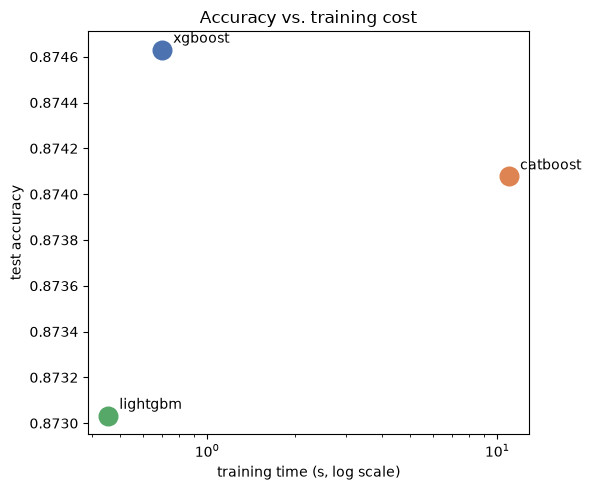

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
for lib in df.index:
    ax.scatter(df.loc[lib, "train_seconds"], df.loc[lib, "accuracy"], s=180, color=colors[lib], label=lib)
    ax.annotate(lib, (df.loc[lib, "train_seconds"], df.loc[lib, "accuracy"]), textcoords="offset points", xytext=(8, 5))

ax.set_xscale("log")
ax.set_xlabel("training time (s, log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("Accuracy vs. training cost")
plt.tight_layout()
plt.savefig("../results/extension_accuracy_vs_speed.png", dpi=150)
plt.show()

## Takeaways

- **Accuracy/AUC are effectively tied** across all three libraries
  (within 0.16pp accuracy, 0.0006 AUC) -- on this dataset, the choice
  of boosting library does not meaningfully change predictive quality.
- **LightGBM is the clear efficiency winner on training** (~35% faster
  than XGBoost, ~24x faster than CatBoost) and produces the smallest
  model file, consistent with its GOSS/EFB design goals.
- **CatBoost trades training speed for inference speed and categorical
  robustness** -- its ordered boosting is expensive per round, but its
  oblivious-tree structure makes prediction the fastest of the three.
- **XGBoost is the balanced generalist**, never fastest on either axis
  but never far behind, which matches its framing in the original paper
  as a system built for practical scalability rather than a single
  narrow metric.
- See `results/extension_results.md` for the full mechanism-level
  discussion of *why* each library lands where it does.